# 06 — Compare forecast inputs and inventory policies fairly

A forecast target and an ordering rule make different contributions to an inventory result. We will change each separately on a five-SKU panel, then cross two forecast inputs with two policies. Every outcome is conditional on the displayed demand, opening stock, timing, and costs.

We will answer three practical questions:

1. With the same order-up-to policy, what changes when we alter the **upper-quantile probability** or the **ETS model**?
2. With the same ANN-95 cumulative target, what changes between an order-up-to rule and a fixed-quantity reorder rule?
3. Across the final 2 × 2 matrix, which scenarios meet a declared per-SKU service floor, and what do they cost on this replay?

A final operational screen illustrates how to read the results. It is a retrospective choice on one held-out path, not a validated deployment decision.

### What “fair” means here

Every branch receives the same dated demand, opening state, lead time, review days, shortage mode, scoring window, and cost rates. We name the forecast or policy field that changes in each comparison. `SimulationEngine.run_comparison()` makes separate copies of mutable policy and inventory objects so a branch cannot change another branch's state.

The forecasts are fitted once at the displayed origin and their targets are held fixed during the 16-day replay. This teaches controlled scenario comparison, not rolling forecast evaluation or statistical model selection.

In [2]:
# Standard-library tools support version checks and target validation.
import importlib.metadata
import math

# pandas holds every declared table; Matplotlib renders the teaching figures.
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Smooth is the separately installed forecasting provider used in this notebook.
from smooth import ES

# Stockcast begins at the forecast-target-to-decision boundary.
from stockcast import (
    InventoryStateDataFrame, OrderUpToPolicy, ReorderPointPolicy,
    SimulationEngine,
)
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, fill_rate, order_units,
    shortage_units, total_cost,
)

The forecast cells use Smooth directly. It is optional external tooling, not a Stockcast dependency. Pinning and printing its version makes the calculation route reproducible; Stockcast consumes the resulting target tables but does not fit ETS models, select a model, or claim authorship of the forecasts. A different forecasting system could supply the same dated direct-target contract.

In [3]:
# Fail early if a different Smooth release could change the public example.
smooth_version = importlib.metadata.version('smooth')
print(f'smooth={smooth_version}')
print(f'pandas={pd.__version__}')

smooth=1.0.7
pandas=3.0.6


## A small panel with explicit operating assumptions

The five series are deterministic tutorial data. History is supplied to Smooth; the later dates are held-out operational demand supplied to Stockcast. The held-out path is deliberately more demanding than the history so conditional trade-offs are visible. It is not a benchmark, a calibrated stress test, or a sample from either fitted model.

The same five SKU identifiers and daily calendar are used everywhere. This lets us pool additive operational quantities across the panel without silently mixing frequencies or misaligning dates.

In [4]:
# One decision period is one calendar day for forecasts, demand, and inventory.
forecast_origin = pd.Timestamp('2026-02-14')
period_frequency = 'D'
lead_time = 2
review_period = 2
protection_horizon = lead_time + review_period

# Two warm-up days advance state but are excluded from reported metrics.
# Only the middle twelve days enter the evaluation metrics.
warmup_periods = 2
scoring_periods = 12
settlement_periods = 2
# The default periodic schedule allows a decision before the first held-out demand.
initial_decision = 'none'
# Settlement advances the last two days without creating new orders.
order_during_settlement = False
demand_source_name = 'declared_five_sku_stress_path'
# Demand is already materialized, so there is no stochastic demand seed.
random_seed = None
allow_backorders = False

print({
    'lead_time': lead_time, 'review_period': review_period,
    'protection_horizon': protection_horizon,
    'warmup/scoring/settlement': (warmup_periods, scoring_periods, settlement_periods),
})

{'lead_time': 2, 'review_period': 2, 'protection_horizon': 4, 'warmup/scoring/settlement': (2, 12, 2)}


In [5]:
# These are the only observations available when the forecasts are fitted.
history_values = {
    'tea':    [5, 6, 5, 7, 6, 8, 7, 6, 9, 8, 7, 9, 8, 10],
    'coffee': [4, 5, 4, 6, 5, 7, 6, 5, 7, 6, 8, 7, 6, 8],
    'pasta':  [5, 4, 5, 6, 5, 6, 7, 5, 6, 7, 6, 7, 8, 6],
    'cereal': [3, 4, 3, 5, 4, 6, 5, 4, 6, 5, 7, 6, 5, 7],
    'soup':   [2, 3, 2, 4, 3, 5, 4, 3, 5, 4, 6, 5, 4, 6],
}
history_dates = pd.date_range(end=forecast_origin, periods=14, freq=period_frequency)
history = pd.concat([
    pd.DataFrame({'unique_id': sku, 'date': history_dates, 'y': values})
    for sku, values in history_values.items()
], ignore_index=True)


In [6]:
# Five SKUs share the same fourteen pre-origin dates: a complete estimation grid.
assert history.groupby('unique_id').size().eq(14).all()
assert history[['unique_id', 'date']].duplicated().sum() == 0
assert history['date'].max() == forecast_origin

print(history.groupby('unique_id')['y'].agg(['count', 'mean', 'min', 'max']).round(2).to_string())
history.head(10)


           count  mean  min  max
unique_id                       
cereal        14  5.00    3    7
coffee        14  6.00    4    8
pasta         14  5.93    4    8
soup          14  4.00    2    6
tea           14  7.21    5   10


,unique_id,date,y
0,tea,2026-02-01,5
1,tea,2026-02-02,6
2,tea,2026-02-03,5
3,tea,2026-02-04,7
4,tea,2026-02-05,6
5,tea,2026-02-06,8
6,tea,2026-02-07,7
7,tea,2026-02-08,6
8,tea,2026-02-09,9
9,tea,2026-02-10,8


The future path is declared directly below. No random-number generator or fitted model creates it. Dates communicate the business calendar; the zero-based `period` column communicates engine timing. Every SKU receives the same 16 period indices, which lets `run_comparison` materialize one common panel demand path for every branch.

In [7]:
holdout_values = {
    'tea':    [9.5, 6.8, 10.8, 8.1, 5.4, 9.5, 8.1, 12.2, 6.8, 8.1, 10.8, 9.5, 5.4, 12.2, 8.1, 6.8],
    'coffee': [5.4, 6.8, 8.1, 6.8, 9.5, 8.1, 5.4, 6.8, 8.1, 9.5, 6.8, 8.1, 5.4, 9.5, 6.8, 8.1],
    'pasta':  [6.8, 5.4, 8.1, 6.8, 5.4, 8.1, 6.8, 5.4, 8.1, 6.8, 9.5, 5.4, 6.8, 8.1, 5.4, 6.8],
    'cereal': [4.1, 6.8, 5.4, 8.1, 6.8, 4.1, 5.4, 8.1, 6.8, 5.4, 8.1, 6.8, 4.1, 8.1, 5.4, 6.8],
    'soup':   [2.7, 4.1, 5.4, 4.1, 6.8, 5.4, 4.1, 2.7, 5.4, 6.8, 4.1, 5.4, 2.7, 6.8, 4.1, 5.4],
}
holdout_dates = pd.date_range(
    start=forecast_origin + pd.Timedelta(days=1), periods=16, freq=period_frequency,
)
holdout = pd.concat([
    pd.DataFrame({'unique_id': sku, 'date': holdout_dates, 'y': values})
    for sku, values in holdout_values.items()
], ignore_index=True)
# Each SKU starts at period zero on the same first held-out date.
holdout['period'] = holdout.groupby('unique_id').cumcount()
# Five SKUs share sixteen dated periods starting the day after the origin.
assert holdout.groupby('unique_id').size().eq(16).all()
assert holdout[['unique_id', 'period']].duplicated().sum() == 0
assert holdout['date'].min() == forecast_origin + pd.Timedelta(days=1)

holdout.head(10)


,unique_id,date,y,period
0,tea,2026-02-15,9.5,0
1,tea,2026-02-16,6.8,1
2,tea,2026-02-17,10.8,2
3,tea,2026-02-18,8.1,3
4,tea,2026-02-19,5.4,4
5,tea,2026-02-20,9.5,5
6,tea,2026-02-21,8.1,6
7,tea,2026-02-22,12.2,7
8,tea,2026-02-23,6.8,8
9,tea,2026-02-24,8.1,9


The panel makes estimation data and operational demand visible together. The dashed line is the forecast origin: values to its left can inform the ETS fits, while values to its right are revealed only to the inventory simulation. The shaded dates are the scoring window; the unshaded held-out dates are warm-up or settlement periods that still advance physical state.

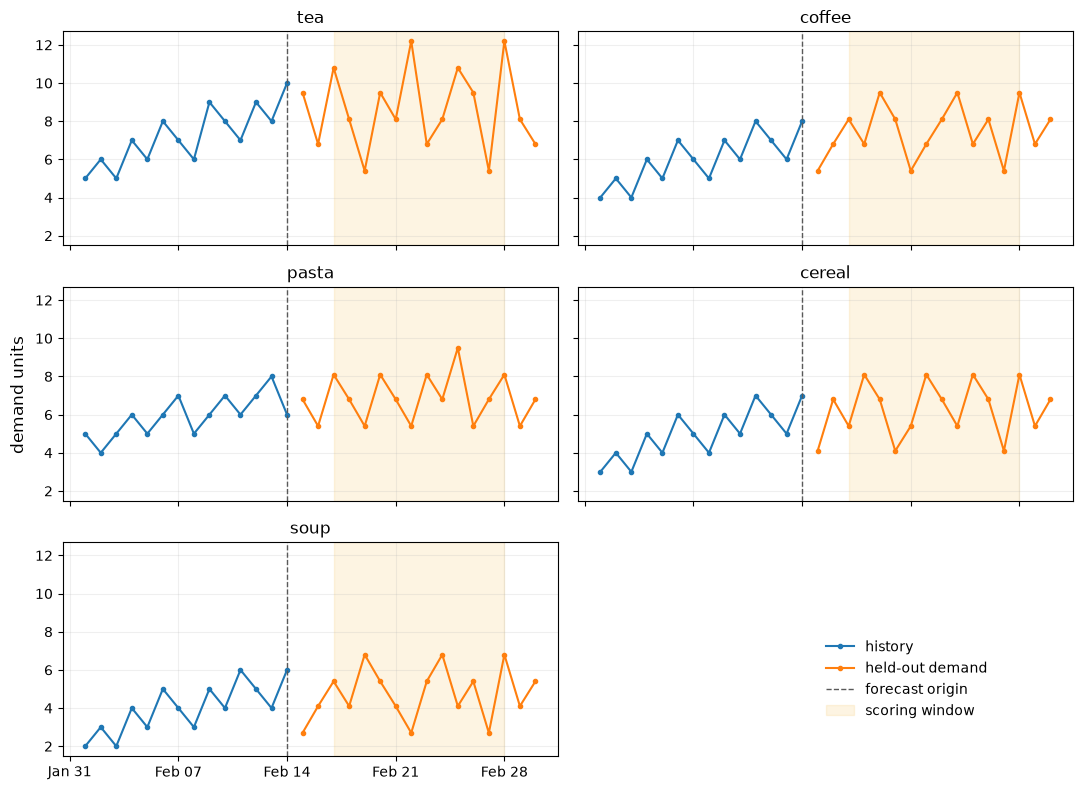

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, sku in zip(axes.flat, history_values):
    past = history[history['unique_id'].eq(sku)]
    future = holdout[holdout['unique_id'].eq(sku)]
    ax.plot(past['date'], past['y'], marker='o', ms=3, label='history')
    ax.plot(future['date'], future['y'], marker='o', ms=3, label='held-out demand')
    ax.axvline(forecast_origin, color='0.35', ls='--', lw=1, label='forecast origin')
    ax.axvspan(holdout_dates[2], holdout_dates[13], color='#f4b942', alpha=.15, label='scoring window')
    ax.set_title(sku)
    ax.grid(alpha=.2)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes.flat[-1].axis('off')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(.92, .08), frameon=False)
fig.supylabel('demand units')
fig.tight_layout()
plt.show()

Opening stock and pipeline are fixed across every branch. Every SKU starts with zero backlog and zero in-transit stock, so opening inventory position equals observed on-hand. Lost sales are enabled (`allow_backorders=False`): unmet demand is recorded as shortage/lost-sales evidence and is not carried into a later period as backlog.

With a two-day lead time, an order cannot satisfy same-period demand. Due pipeline stock is received before that period's demand is served, and every positive decision records its expected delivery period explicitly.

In [9]:
# Preserve one stable SKU order in tables and plots.
skus = list(history_values)
opening_stock = pd.DataFrame({
    'unique_id': skus,
    'observed_on_hand': [12.0, 11.0, 10.0, 9.0, 8.0],
})
opening_stock


,unique_id,observed_on_hand
0,tea,12.0
1,coffee,11.0
2,pasta,10.0
3,cereal,9.0
4,soup,8.0


In [10]:
# max_lead_time allocates the two pipeline slots required by this scenario.
# The engine deep-copies this state per branch; the caller-owned object is preserved.
opening_inventory = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=allow_backorders,
).initialize_from_observed(
    opening_stock, on_hand_column='observed_on_hand', start_date=forecast_origin,
)
opening_inventory


InventoryStateDataFrame(n_skus=5, total_on_hand=50, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [11]:
print('Explicit opening state')
print(opening_inventory.inventory_position()[[
    'unique_id', 'on_hand', 'backorders', 'total_in_transit', 'inventory_position',
]].to_string(index=False))


Explicit opening state
unique_id  on_hand  backorders  total_in_transit  inventory_position
      tea     12.0         0.0               0.0                12.0
   coffee     11.0         0.0               0.0                11.0
    pasta     10.0         0.0               0.0                10.0
   cereal      9.0         0.0               0.0                 9.0
     soup      8.0         0.0               0.0                 8.0


Costs are evaluation assumptions, not engine inputs: they value validated event rows after simulation and therefore cannot change physical decisions. We activate only holding, shortage, and ordering costs. Holding cost is charged per ending unit per scored SKU-period; shortage cost is charged per unmet unit; ordering cost is charged per positive SKU order line. Explicit zero unit-order cost means order size has no variable purchasing charge in this tutorial.

No purchase, backlog, waste, terminal-pipeline, or salvage component is silently included. Changing the active components or rates would define a different economic comparison even if the physical runs stayed identical.

In [12]:
# total_cost will fail closed unless this active-component list is explicit.
cost_context = {
    'cost_components': ['holding', 'shortage', 'ordering'],
    'holding_cost_per_unit_period': 0.20,
    'shortage_cost_per_unit': 5.00,
    'order_cost_per_sku_line': 1.50,
    'order_cost_per_unit': 0.00,
}
print(pd.Series(cost_context, name='declared value').to_string())

cost_components                 [holding, shortage, ordering]
holding_cost_per_unit_period                              0.2
shortage_cost_per_unit                                    5.0
order_cost_per_sku_line                                   1.5
order_cost_per_unit                                       0.0


## Build cumulative upper-quantile targets outside Stockcast

For each SKU, Smooth fits two ETS configurations to **history only**: ANN has no trend, while AAN includes an additive trend. We ask each fitted model for direct 90% and 95% upper quantiles of **total future demand**. These are quantiles *of cumulative demand*, not point forecasts and not sums of daily quantiles.

We request a 2-day lead-time total and a 4-day `L+R` protection total. The 2-day column illustrates how much the horizon changes the answer. Both policies compared below will use the **same 4-day target**: `S` for order-up-to and `s` for the fixed-quantity rule. A quantile level is a model input, not a guarantee of realized fill rate.

In [13]:
# This table states the forecast dimensions we deliberately vary.
forecast_design = pd.DataFrame([
    {'ets_model': 'ANN', 'model_change': 'no trend', 'probabilities': '0.90, 0.95'},
    {'ets_model': 'AAN', 'model_change': 'additive trend', 'probabilities': '0.90, 0.95'},
])
print(forecast_design.to_string(index=False))

ets_model   model_change probabilities
      ANN       no trend    0.90, 0.95
      AAN additive trend    0.90, 0.95


This short loop is forecasting work, not a wrapper around the Stockcast comparison API. One model is fitted independently per SKU; there is no pooling or cross-series information sharing. Each catalogue row records the exact model, probability, horizon, dates, provider, package version, source type, and representation used to obtain its direct cumulative target.

The catalogue is the handoff boundary: everything above it estimates forecast-derived information, while the policy cells below consume already-calculated targets. Keeping the boundary as a printed DataFrame makes it possible to audit or replace the forecasting provider without changing engine behavior.

In [14]:
# Accumulate one provenance-complete row per SKU/model/probability tuple.
target_rows = []
for sku in skus:
    # A reset Series gives smooth an explicit integer index without changing values.
    series = history.loc[history['unique_id'].eq(sku), 'y'].reset_index(drop=True)
    for ets_model in ['ANN', 'AAN']:
        # Fit only the declared pre-origin observations for this SKU.
        fitted_model = ES(ets_model).fit(series)
        for probability in [0.90, 0.95]:
            # side='upper' means level=.90/.95 is the upper-tail quantile itself,
            # rather than the upper endpoint of a two-sided central interval.
            lead_forecast = fitted_model.predict(
                h=lead_time, interval='prediction', level=probability,
                side='upper', cumulative=True,
            ).to_dataframe()
            protection_forecast = fitted_model.predict(
                h=protection_horizon, interval='prediction', level=probability,
                side='upper', cumulative=True,
            ).to_dataframe()
            # Each result contains the direct cumulative endpoint at its horizon.
            lead_target = lead_forecast.filter(regex='^upper_').iloc[-1, 0]
            protection_target = protection_forecast.filter(regex='^upper_').iloc[-1, 0]
            # Store both the numeric targets and enough metadata to reproduce them.
            target_rows.append({
                'unique_id': sku,
                'ets_model': ets_model,
                'target_probability': probability,
                'lead_time_target': float(lead_target),
                'lead_time_horizon': lead_time,
                'lead_time_end_date': forecast_origin + pd.Timedelta(days=lead_time),
                'protection_target': float(protection_target),
                'protection_horizon': protection_horizon,
                'target_end_date': forecast_origin + pd.Timedelta(days=protection_horizon),
                'forecast_origin': forecast_origin,
                'forecast_frequency': period_frequency,
                'target_source': 'external_direct',
                'forecast_provider': 'smooth',
                'smooth_version': smooth_version,
                'representation': 'direct_cumulative_upper_quantile',
            })
target_catalogue = pd.DataFrame(target_rows)

Before fitting policies, fail closed if the catalogue is incomplete, duplicated, non-finite, negative, misdated, or internally inconsistent. Exactly 20 rows are required: five SKUs × two ETS configurations × two probabilities. The 95% upper target must not fall below the corresponding 90% target for the same SKU, model, and horizon. These checks validate the declared handoff structure; they do not establish forecast calibration or model quality.

In [15]:
# Enumerate the exact keys that a complete 5 × 2 × 2 catalogue must contain.
expected_keys = pd.MultiIndex.from_product(
    [skus, ['ANN', 'AAN'], [0.90, 0.95]],
    names=['unique_id', 'ets_model', 'target_probability'],
)
actual_keys = pd.MultiIndex.from_frame(target_catalogue[list(expected_keys.names)])
if len(target_catalogue) != 20 or len(actual_keys.unique()) != 20 or set(actual_keys) != set(expected_keys):
    raise ValueError('forecast target catalogue is incomplete or duplicated')
# Scientific inputs must be finite and physically non-negative.
target_values = target_catalogue[['lead_time_target', 'protection_target']]
if not all(math.isfinite(value) for value in target_values.to_numpy().ravel()):
    raise ValueError('forecast targets must be finite')
if (target_values < 0).any().any():
    raise ValueError('forecast targets must be non-negative')
# Target end dates must agree with the stated origin, frequency, and horizons.
if not target_catalogue['lead_time_end_date'].eq(
    forecast_origin + pd.Timedelta(days=lead_time)
).all():
    raise ValueError('lead-time target date does not match its horizon')
if not target_catalogue['target_end_date'].eq(
    forecast_origin + pd.Timedelta(days=protection_horizon)
).all():
    raise ValueError('protection target date does not match its horizon')
# For one-sided upper quantiles, increasing probability cannot lower the target.
ordered = target_catalogue.sort_values('target_probability')
for column in ['lead_time_target', 'protection_target']:
    differences = ordered.groupby(['unique_id', 'ets_model'])[column].diff().dropna()
    if (differences < 0).any():
        raise ValueError(f'95% {column} falls below its 90% counterpart')
print('Catalogue rows per model and probability')
print(target_catalogue.groupby(['ets_model', 'target_probability']).size().to_string())
print('\nCatalogue head (20 rows total: 5 SKUs x 2 models x 2 probabilities)')
print(target_catalogue[[
    'unique_id', 'ets_model', 'target_probability',
    'lead_time_target', 'protection_target',
 ]].head(8).round(2).to_string(index=False))


Catalogue rows per model and probability
ets_model  target_probability
AAN        0.90                  5
           0.95                  5
ANN        0.90                  5
           0.95                  5

Catalogue head (20 rows total: 5 SKUs x 2 models x 2 probabilities)
unique_id ets_model  target_probability  lead_time_target  protection_target
      tea       ANN                0.90             20.82              41.54
      tea       ANN                0.95             21.67              43.22
      tea       AAN                0.90             20.91              41.97
      tea       AAN                0.95             21.46              42.78
   coffee       ANN                0.90             16.87              33.54
   coffee       ANN                0.95             17.62              34.98
   coffee       AAN                0.90             17.40              34.77
   coffee       AAN                0.95             17.92              35.52


The left chart changes the ETS model at a fixed 95% probability; the right changes probability within ANN. Both display the **4-day cumulative upper target** for each SKU. They show what information the policies will consume. They do not score the forecasts against realized demand yet.

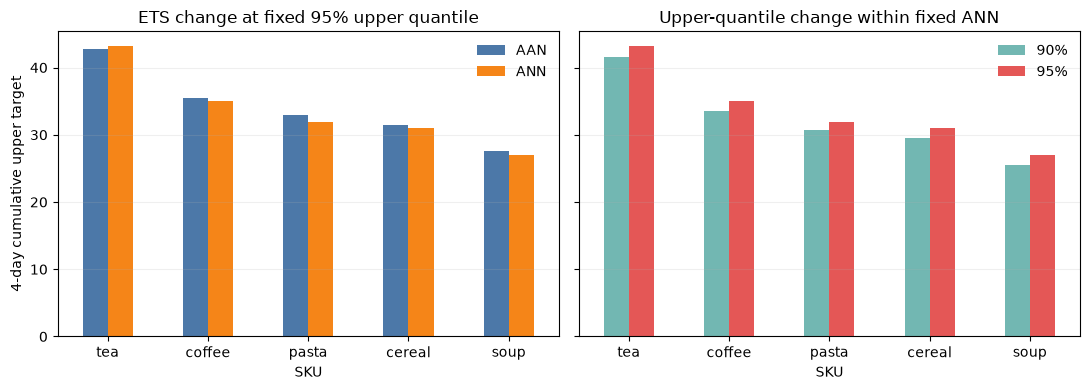

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
model_targets = target_catalogue[target_catalogue['target_probability'].eq(.95)].pivot(
    index='unique_id', columns='ets_model', values='protection_target',
).reindex(skus)
quantile_targets = target_catalogue[target_catalogue['ets_model'].eq('ANN')].pivot(
    index='unique_id', columns='target_probability', values='protection_target',
).reindex(skus)
model_targets.plot.bar(ax=axes[0], color=['#4c78a8', '#f58518'])
quantile_targets.rename(columns={.90: '90%', .95: '95%'}).plot.bar(
    ax=axes[1], color=['#72b7b2', '#e45756'],
)
axes[0].set_title('ETS change at fixed 95% upper quantile')
axes[1].set_title('Upper-quantile change within fixed ANN')
for ax in axes:
    ax.set_xlabel('SKU')
    ax.set_ylabel('4-day cumulative upper target')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=.2)
    ax.legend(title=None, frameon=False)
fig.tight_layout()
plt.show()

### Check the forecast targets against the first protection window

For this one forecast origin, realized demand over the first four held-out days is the matching observation for each 4-day target. `hit` says whether that observation fell below the predicted upper quantile. Pinball loss penalizes a miss more heavily at 95% than at 90%, as a quantile score should. This is **five SKUs at one origin**: useful to inspect, far too little evidence to claim calibration or select an ETS model. We do not use these realized totals to fit targets or choose policy parameters.

Compare pinball loss **between ETS models at the same probability**; 90% and 95% scores answer different quantile questions. A hit count of five out of five at one origin does not establish 90% or 95% calibration.

In [17]:
actual_four_day = (
    holdout.loc[holdout['period'].lt(protection_horizon)]
    .groupby('unique_id', as_index=False)['y'].sum()
    .rename(columns={'y': 'realized_4_day_demand'})
)
forecast_check = target_catalogue.merge(actual_four_day, on='unique_id', validate='many_to_one')
error = forecast_check['realized_4_day_demand'] - forecast_check['protection_target']
p = forecast_check['target_probability']
forecast_check['hit'] = error.le(0)
forecast_check['pinball_loss'] = np.where(error.ge(0), p * error, (p - 1) * error)

# Keep only the three inputs used in the controlled forecast comparison.
checked = forecast_check.loc[
    forecast_check['ets_model'].eq('ANN') | forecast_check['target_probability'].eq(.95)
].copy()
wide = checked.pivot(index='unique_id', columns=['ets_model', 'target_probability'],
                     values='protection_target').reindex(skus)
wide = wide[[('ANN', .90), ('ANN', .95), ('AAN', .95)]]
wide.columns = ['ANN 90% target', 'ANN 95% target', 'AAN 95% target']
wide.insert(0, 'realized 4-day demand', actual_four_day.set_index('unique_id').reindex(skus)['realized_4_day_demand'])
print(wide.round(2).to_string())
print('\nOne-origin quantile diagnostics (five SKU totals per input):')
print(checked.groupby(['ets_model', 'target_probability']).agg(
    hits=('hit', 'sum'), mean_pinball_loss=('pinball_loss', 'mean'),
).round(3).to_string())

           realized 4-day demand  ANN 90% target  ANN 95% target  AAN 95% target
unique_id                                                                       
tea                         35.2           41.54           43.22           42.78
coffee                      27.1           33.54           34.98           35.52
pasta                       27.1           30.78           31.97           32.88
cereal                      24.4           29.54           30.98           31.52
soup                        16.3           25.54           26.98           27.52

One-origin quantile diagnostics (five SKU totals per input):
                              hits  mean_pinball_loss
ets_model target_probability                         
AAN       0.95                   5              0.401
ANN       0.90                   5              0.617
          0.95                   5              0.380


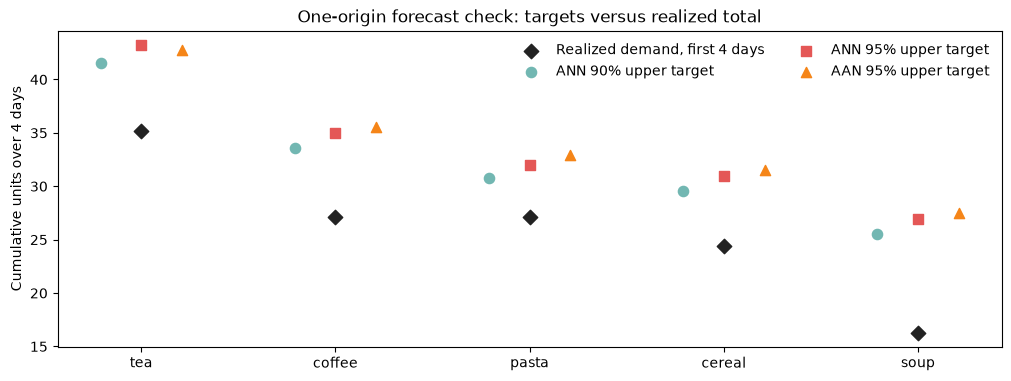

In [18]:
# Dot positions separate categorical SKU targets without implying a continuous SKU axis.
fig, ax = plt.subplots(figsize=(10, 3.7), layout='constrained')
x = np.arange(len(skus))
actual = actual_four_day.set_index('unique_id').reindex(skus)['realized_4_day_demand']
ax.scatter(x, actual, color='#222222', marker='D', s=54,
           label='Realized demand, first 4 days', zorder=3)
for label, model, probability, color, marker, offset in [
    ('ANN 90%', 'ANN', .90, '#72b7b2', 'o', -.21),
    ('ANN 95%', 'ANN', .95, '#e45756', 's', 0),
    ('AAN 95%', 'AAN', .95, '#f58518', '^', .21),
]:
    values = target_catalogue.query('ets_model == @model and target_probability == @probability')
    ax.scatter(x + offset, values.set_index('unique_id').reindex(skus)['protection_target'],
               color=color, marker=marker, s=54, label=f'{label} upper target')
ax.set_xticks(x, skus)
ax.set(ylabel='Cumulative units over 4 days',
       title='One-origin forecast check: targets versus realized total')
ax.legend(frameon=False, ncol=2)
plt.show()

## Comparison 1 — change forecast information, keep the policy family fixed

We select ANN-90, ANN-95, and AAN-95. In an \(R,S\) policy, \(R=2\) means the inventory position is reviewed every two days and \(S\) is the SKU-specific 4-day protection target. On a review date the requested quantity is the non-negative gap between \(S\) and current inventory position.

All branches use that same equation, lead time, review period, opening state, demand, shortage mode, timing windows, and costs. The policy's `service_level` must match target probability by API contract, so it is 0.90 for ANN-90 and 0.95 for the other branches. This field validates provenance compatibility; it does not promise that realized fill rate will equal 90% or 95% in sixteen days.

- **ANN-90 vs ANN-95** changes upper-quantile probability and its required matching policy probability.
- **ANN-95 vs AAN-95** changes only the ETS configuration.

Reading any other pair—for example ANN-90 versus AAN-95—changes two forecast dimensions at once and therefore cannot isolate a model-only or probability-only effect.

In [19]:
# Copy three complete five-SKU slices so later policy fits cannot alias the catalogue.
ann90_targets = target_catalogue.query(
    "ets_model == 'ANN' and target_probability == 0.90"
).copy()
ann95_targets = target_catalogue.query(
    "ets_model == 'ANN' and target_probability == 0.95"
).copy()
aan95_targets = target_catalogue.query(
    "ets_model == 'AAN' and target_probability == 0.95"
).copy()

# Fit the first policy from the ANN 90% four-day protection targets.
ann90_policy = OrderUpToPolicy(
    lead_time=lead_time, review_period=review_period, service_level=.90,
    allow_backorders=allow_backorders,
).fit(
    ann90_targets, target_column='protection_target', target_probability=.90,
    protection_horizon=protection_horizon, target_source='external_direct',
    forecast_origin=forecast_origin, forecast_frequency=period_frequency,
    target_end_date_column='target_end_date',
)

In [20]:
# Keep the ANN model and consume its higher-probability 95% target slice.
ann95_policy = OrderUpToPolicy(
    lead_time=lead_time, review_period=review_period, service_level=.95,
    allow_backorders=allow_backorders,
).fit(
    ann95_targets, target_column='protection_target', target_probability=.95,
    protection_horizon=protection_horizon, target_source='external_direct',
    forecast_origin=forecast_origin, forecast_frequency=period_frequency,
    target_end_date_column='target_end_date',
)

# Keep probability at 95% and change only the ETS structure to additive trend.
aan95_policy = OrderUpToPolicy(
    lead_time=lead_time, review_period=review_period, service_level=.95,
    allow_backorders=allow_backorders,
).fit(
    aan95_targets, target_column='protection_target', target_probability=.95,
    protection_horizon=protection_horizon, target_source='external_direct',
    forecast_origin=forecast_origin, forecast_frequency=period_frequency,
    target_end_date_column='target_end_date',
)

In [21]:
# One comparison call gives every branch the same materialized demand rows.
# The engine deep-copies opening inventory and fitted policies per branch,
# preventing one simulation's mutable state from leaking into another.
forecast_comparison = SimulationEngine().run_comparison(
    policies=[ann90_policy, ann95_policy, aan95_policy],
    labels=['ANN 90% + (R,S)', 'ANN 95% + (R,S)', 'AAN 95% + (R,S)'],
    demand_source=holdout, inventory=opening_inventory,
    n_periods=len(holdout_dates), period_frequency=period_frequency,
    initial_decision=initial_decision, warmup_periods=warmup_periods,
    scoring_periods=scoring_periods, settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name=demand_source_name, random_seed=random_seed,
)

Evaluation reads only validated scoring-window event rows. We pool the panel deliberately (`groupby=[]`), so each output row summarizes one scenario across all five SKUs and twelve scored days. The metrics answer different operational questions:

- `fill_rate`: fulfilled demand units divided by demand units, pooled across the panel;
- `shortage_units`: the additive quantity of demand not fulfilled immediately;
- `avg_on_hand`: mean ending on-hand across scored SKU-period rows;
- `order_units`: additive units requested during the scoring window;
- `total_cost`: only the declared holding, shortage, and SKU-line ordering components.

Pooling is explicit rather than automatically averaging per-SKU service rates. A per-SKU diagnosis would instead pass `groupby=['unique_id']`.

In [22]:
# Evaluate each branch with the identical window, metric list, grain, and costs.
forecast_metric_rows = []
for label, result in forecast_comparison.results.items():
    row = InventoryEvaluator().fit(result, window='scoring').evaluate(
        metrics=[fill_rate, shortage_units, avg_on_hand, order_units, total_cost],
        groupby=[], context=cost_context,
    ).iloc[0].to_dict()
    # Keep the engine label beside its pooled metric row.
    row['scenario'] = label
    forecast_metric_rows.append(row)
forecast_metrics = pd.DataFrame(forecast_metric_rows).set_index('scenario')
print(forecast_metrics.round(3).to_string())

                 fill_rate  shortage_units  avg_on_hand  order_units  total_cost
scenario                                                                        
ANN 90% + (R,S)        1.0             0.0        8.463        400.9     146.562
ANN 95% + (R,S)        1.0             0.0        9.903        400.9     163.832
AAN 95% + (R,S)        1.0             0.0       10.323        400.9     168.878


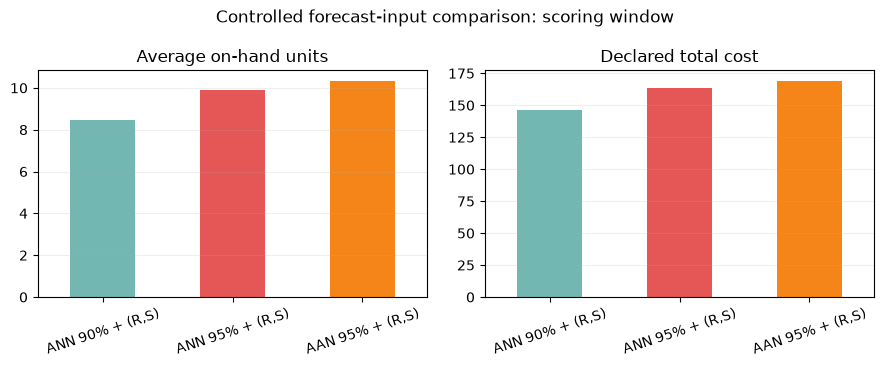

In [23]:
# Plot metrics that visibly separate these no-shortage forecast branches.
forecast_plot_specs = [
    ('avg_on_hand', 'Average on-hand units'),
    ('total_cost', 'Declared total cost'),
]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.7))
for ax, (column, title) in zip(axes, forecast_plot_specs):
    forecast_metrics[column].plot.bar(
        ax=ax, color=['#72b7b2', '#e45756', '#f58518'],
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=18)
    ax.grid(axis='y', alpha=.2)
fig.suptitle('Controlled forecast-input comparison: scoring window')
fig.tight_layout()
plt.show()

**Conditional reading.** All three branches avoid shortages on this path, so fill rate and shortage units are equal in the table. That equality is informative: higher targets do not buy additional fulfilled units in this particular window. Within ANN, 95% raises every target and carries more average stock than 90%. At fixed 95%, AAN changes every target (raising four of five) and increases pooled average stock here. Because order units are equal, the displayed cost difference comes from holding more ending inventory, not purchasing more units.

This does not prove that 90%, 95%, ANN, or AAN is universally better. A longer window, different history, different realized demand, or a larger shortage penalty could change both the operational trade-off and the economically preferred branch.

## The second policy: fixed quantity at a reorder point

Notebook 05 builds a custom `(s,Q)` rule to teach the policy interface; Notebook 05b uses Stockcast's built-in `ReorderPointPolicy`. Here we use the built-in class so the comparison stays focused on the **operating decision**. At every two-day review, `(s,Q)` orders `Q=14` units when inventory position is at or below `s`. Inventory position includes on-hand and in-transit stock, less backlog; this scenario uses lost sales, so backlog stays zero.

The 4-day ANN-95 upper target supplies `s`. The order-up-to policy uses that **same numeric target** as `S` and orders the gap `max(0, S − IP)` on every review. A common target does not make the policies equivalent: one changes order size with the gap, while the other orders a fixed quantity after a threshold test. `Q=14` is a declared scenario parameter, not an optimized value.

In [24]:
# The built-in rule owns the threshold check and returns an OrderDecision.
# The forecast target is reused as s over the same L+R protection window.
def fit_fixed_quantity(target_slice, probability):
    return ReorderPointPolicy(
        lead_time=lead_time, review_period=review_period, policy_type='sQ',
        service_level=probability, order_quantity=14.0,
        order_quantity_source='declared tutorial Q=14 units per SKU order',
        allow_backorders=allow_backorders,
    ).fit(
        target_slice, forecast_origin=forecast_origin,
        forecast_frequency=period_frequency,
        reorder_point_column='protection_target',
        reorder_end_date_column='target_end_date',
        reorder_horizon=protection_horizon,
        target_source='external_direct', target_probability=probability,
    )

## Comparison 2 — keep the ANN-95 target fixed, change the policy

Both branches use the same 4-day ANN-95 quantile for every SKU, the same two-day review schedule, and the same physical experiment. We change only the ordering rule and its declared fixed quantity. The target has two different roles: an order-up-to level `S` in `(R,S)`, and a trigger `s` in `(s,Q)`. This isolates a clearer policy contrast than giving the threshold a shorter forecast horizon.

In [25]:
ann95_sQ_policy = fit_fixed_quantity(ann95_targets, .95)
policy_inputs = ann95_targets[['unique_id', 'protection_target']].rename(
    columns={'protection_target': 'shared 4-day target: S or s'},
)
policy_inputs['fixed Q for (s,Q)'] = ann95_sQ_policy.order_quantity
print(policy_inputs.round(2).to_string(index=False))
# Both policies retain dated target provenance, even though their equations differ.
assert ann95_policy.get_target_metadata()['protection_horizon'] == protection_horizon
assert ann95_sQ_policy.get_target_metadata()['reorder_horizon'] == protection_horizon

unique_id  shared 4-day target: S or s  fixed Q for (s,Q)
      tea                        43.22               14.0
   coffee                        34.98               14.0
    pasta                        31.97               14.0
   cereal                        30.98               14.0
     soup                        26.98               14.0


In [26]:
# This second engine call changes policy family while preserving the experiment.
policy_comparison = SimulationEngine().run_comparison(
    policies=[ann95_policy, ann95_sQ_policy],
    labels=['ANN 95% + (R,S)', 'ANN 95% + (s,Q)'],
    demand_source=holdout, inventory=opening_inventory,
    n_periods=len(holdout_dates), period_frequency=period_frequency,
    initial_decision=initial_decision, warmup_periods=warmup_periods,
    scoring_periods=scoring_periods, settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name=demand_source_name, random_seed=random_seed,
)

# Reuse the exact scoring, grouping, metric, and cost contract from Comparison 1.
policy_metric_rows = []
for label, result in policy_comparison.results.items():
    row = InventoryEvaluator().fit(result, window='scoring').evaluate(
        metrics=[fill_rate, shortage_units, avg_on_hand, order_units, total_cost],
        groupby=[], context=cost_context,
    ).iloc[0].to_dict()
    row['scenario'] = label
    policy_metric_rows.append(row)
policy_metrics = pd.DataFrame(policy_metric_rows).set_index('scenario')
print(policy_metrics.round(3).to_string())

                 fill_rate  shortage_units  avg_on_hand  order_units  total_cost
scenario                                                                        
ANN 95% + (R,S)      1.000             0.0        9.903        400.9     163.832
ANN 95% + (s,Q)      0.923            32.3        6.318        406.0     280.820


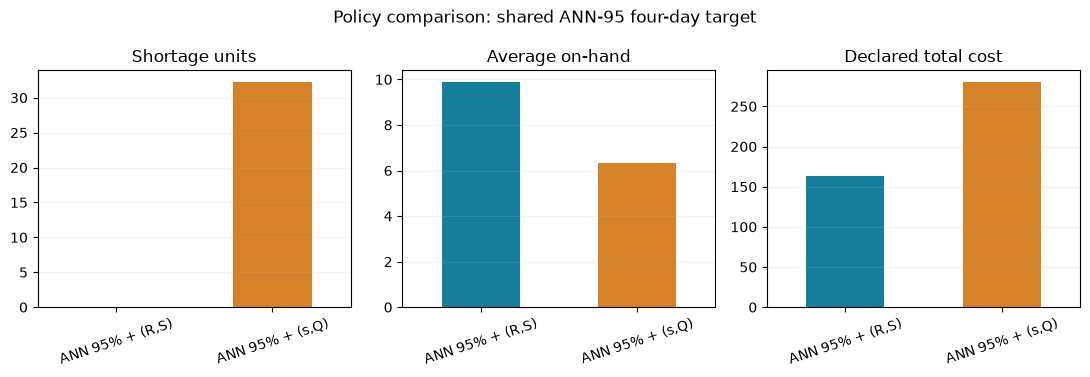

In [27]:
# Show the central service-stock-cost trade-off for the two policy equations.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, column, title in zip(
    axes, ['shortage_units', 'avg_on_hand', 'total_cost'],
    ['Shortage units', 'Average on-hand', 'Declared total cost'],
):
    policy_metrics[column].plot.bar(ax=ax, color=['#167d9a', '#d58228'])
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=18)
    ax.grid(axis='y', alpha=.2)
fig.suptitle('Policy comparison: shared ANN-95 four-day target')
fig.tight_layout()
plt.show()

**Conditional reading.** Compare service, stock, order volume, and declared cost together. The fixed `Q` may save stock or ordering effort, but can also leave demand unfilled if it is too small for this path. The order-up-to rule responds to the full gap to its target. The table and the dated trajectory below show what happened under these particular assumptions; neither rule is universally preferable.

## Combined 2 × 2 forecast-by-policy matrix

Now cross **ANN-95 versus AAN-95** with **`(R,S)` versus `(s,Q)`**. Every cell uses the same 4-day cumulative target *horizon* and its policy's declared order equation. This matrix has controlled directions:

- within a forecast row, change only the policy rule;
- within a policy column, change only the ETS configuration at fixed 95% probability;
- diagonal differences change both and cannot identify either effect alone.

The 90% versus 95% contrast was already isolated in Comparison 1. `Q=14` stays fixed across the matrix. Before running them, declare the operating screen: each SKU must reach at least 95% scored fill rate; among qualifying scenarios, choose the lowest declared portfolio cost. These four scenarios let us apply that rule after the shared replay.

In [28]:
# The AAN branch uses the same built-in rule, Q, review schedule, and horizon.
aan95_sQ_policy = fit_fixed_quantity(aan95_targets, .95)
matrix_design = pd.DataFrame([
    ['ANN 95%', '(R,S)', '4-day q95 as S'],
    ['ANN 95%', '(s,Q)', '4-day q95 as s; Q=14'],
    ['AAN 95%', '(R,S)', '4-day q95 as S'],
    ['AAN 95%', '(s,Q)', '4-day q95 as s; Q=14'],
], columns=['forecast input', 'policy', 'forecast-derived role'])
print(matrix_design.to_string(index=False))

forecast input policy forecast-derived role
       ANN 95%  (R,S)        4-day q95 as S
       ANN 95%  (s,Q)  4-day q95 as s; Q=14
       AAN 95%  (R,S)        4-day q95 as S
       AAN 95%  (s,Q)  4-day q95 as s; Q=14


In [29]:
# The third comparison call evaluates all four cells on one shared experiment.
matrix_comparison = SimulationEngine().run_comparison(
    policies=[ann95_policy, ann95_sQ_policy, aan95_policy, aan95_sQ_policy],
    labels=[
        'ANN 95% | (R,S)', 'ANN 95% | (s,Q)',
        'AAN 95% | (R,S)', 'AAN 95% | (s,Q)',
    ],
    demand_source=holdout, inventory=opening_inventory,
    n_periods=len(holdout_dates), period_frequency=period_frequency,
    initial_decision=initial_decision, warmup_periods=warmup_periods,
    scoring_periods=scoring_periods, settlement_periods=settlement_periods,
    order_during_settlement=order_during_settlement,
    demand_source_name=demand_source_name, random_seed=random_seed,
)

# Apply one evaluation contract to every matrix cell.
matrix_metric_rows = []
for label, result in matrix_comparison.results.items():
    row = InventoryEvaluator().fit(result, window='scoring').evaluate(
        metrics=[fill_rate, shortage_units, avg_on_hand, order_units, total_cost],
        groupby=[], context=cost_context,
    ).iloc[0].to_dict()
    row['scenario'] = label
    matrix_metric_rows.append(row)
matrix_metrics = pd.DataFrame(matrix_metric_rows).set_index('scenario')
print(matrix_metrics.round(3).to_string())

                 fill_rate  shortage_units  avg_on_hand  order_units  total_cost
scenario                                                                        
ANN 95% | (R,S)      1.000             0.0        9.903        400.9     163.832
ANN 95% | (s,Q)      0.923            32.3        6.318        406.0     280.820
AAN 95% | (R,S)      1.000             0.0       10.323        400.9     168.878
AAN 95% | (s,Q)      0.923            32.3        6.318        406.0     280.820


The two `(s,Q)` rows have the same service and cost even though ANN and AAN produced different 4-day targets. The fixed quantity and the inventory positions led both thresholds to the **same decisions** on this path. This is an important operational result: a changed forecast need not change an order. The next assertion checks that explanation against the validated order rows.

In [30]:
ann_sq_orders = matrix_comparison.results['ANN 95% | (s,Q)'].to_event_frame()
aan_sq_orders = matrix_comparison.results['AAN 95% | (s,Q)'].to_event_frame()
assert ann_sq_orders[['unique_id', 'date']].equals(aan_sq_orders[['unique_id', 'date']])
assert np.allclose(ann_sq_orders['order_quantity'], aan_sq_orders['order_quantity'])
print('ANN-95 and AAN-95 (s,Q): identical accepted orders on all 80 SKU-days.')

ANN-95 and AAN-95 (s,Q): identical accepted orders on all 80 SKU-days.


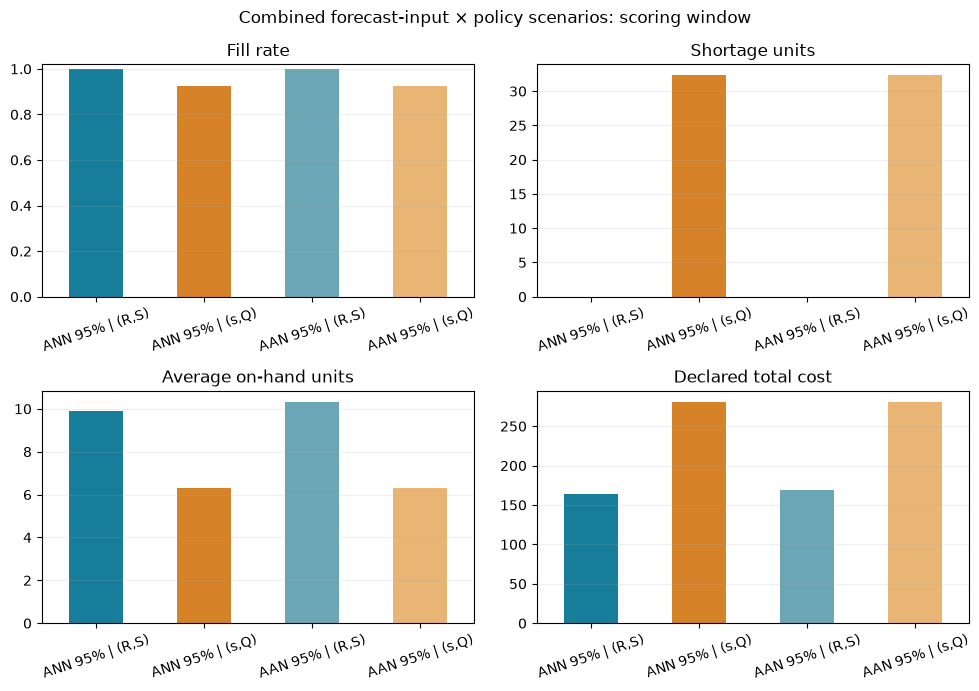

In [31]:
# Use a shared color per matrix cell across all four aggregate metrics.
matrix_plot_specs = [
    ('fill_rate', 'Fill rate', (0, 1.02)),
    ('shortage_units', 'Shortage units', None),
    ('avg_on_hand', 'Average on-hand units', None),
    ('total_cost', 'Declared total cost', None),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (column, title, ylim) in zip(axes.flat, matrix_plot_specs):
    matrix_metrics[column].plot.bar(
        ax=ax, color=['#167d9a', '#d58228', '#6aa6b6', '#e8b575'],
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=18)
    ax.grid(axis='y', alpha=.2)
    if ylim:
        ax.set_ylim(*ylim)
fig.suptitle('Combined forecast-input × policy scenarios: scoring window')
fig.tight_layout()
plt.show()

### Why the policy branches differ on actual dates

The aggregate bars hide the sequence of orders, arrivals, and demand. For tea, the next figure uses the same realized demand in both ANN-95 branches. End-of-day on-hand is plotted after that day's receipts and demand; circles mark receipt days at that ending stock level. The lower panel shows **accepted orders on decision dates**, so its bars should not be read as same-day receipts.

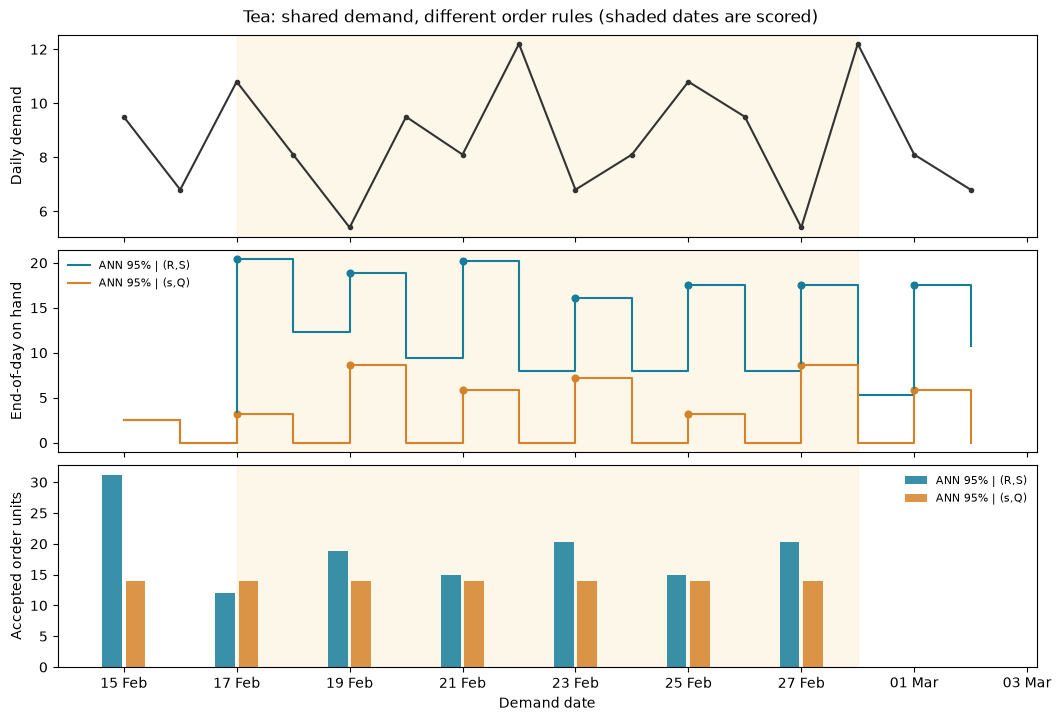

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(10.5, 7.1), sharex=True, layout='constrained')
colors = {'ANN 95% | (R,S)': '#167d9a', 'ANN 95% | (s,Q)': '#d58228'}
for label, color in colors.items():
    tea = matrix_comparison.results[label].to_event_frame().query("unique_id == 'tea'")
    axes[1].step(tea['date'], tea['ending_on_hand'], where='post', color=color, label=label)
    received = tea.loc[tea['received_units'].gt(0)]
    axes[1].scatter(received['date'], received['ending_on_hand'], color=color, marker='o', s=23)
    shift = pd.Timedelta(hours=-5 if label.endswith('(R,S)') else 5)
    axes[2].bar(tea['date'] + shift, tea['order_quantity'], width=.35,
                color=color, alpha=.85, label=label, align='center')
axes[0].plot(holdout_dates, holdout.query("unique_id == 'tea'")['y'],
             color='#333333', marker='o', ms=3)
for ax in axes:
    ax.axvspan(holdout_dates[warmup_periods],
               holdout_dates[warmup_periods + scoring_periods - 1],
               color='#f4b942', alpha=.11, zorder=-1)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[0].set_ylabel('Daily demand')
axes[1].set_ylabel('End-of-day on hand')
axes[2].set_ylabel('Accepted order units')
axes[2].set_xlabel('Demand date')
axes[1].legend(frameon=False, fontsize=8)
axes[2].legend(frameon=False, fontsize=8)
fig.suptitle('Tea: shared demand, different order rules (shaded dates are scored)')
plt.show()

### An explicit operating screen

Suppose the buyer requires **at least 95% fill rate for every SKU** on the scored dates, then chooses the lowest declared portfolio cost among scenarios that qualify. We calculate per-SKU fill rates rather than relying on the pooled rate alone. The service floor was declared before the matrix was run. It uses the notebook's holding, shortage, and per-order-line rates; it includes no other costs. The selected scenario is the cheapest **in this one replay under this screen**, not a fitted optimum or a deployment recommendation.

In [33]:
minimum_sku_fill = 0.95
per_sku_rows = []
for label, result in matrix_comparison.results.items():
    by_sku = InventoryEvaluator().fit(result, window='scoring').evaluate(
        metrics=[fill_rate], groupby=['unique_id'], context={},
    )
    by_sku['scenario'] = label
    per_sku_rows.append(by_sku)
per_sku_service = pd.concat(per_sku_rows, ignore_index=True)
screen = matrix_metrics[['fill_rate', 'total_cost']].copy()
screen['worst_sku_fill'] = per_sku_service.groupby('scenario')['fill_rate'].min()
screen['meets_each_sku_floor'] = screen['worst_sku_fill'].ge(minimum_sku_fill)
print(screen.round(3).to_string())
eligible = screen.loc[screen['meets_each_sku_floor']]
if eligible.empty:
    print('No scenario meets the declared service floor on this replay.')
else:
    chosen = eligible['total_cost'].idxmin()
    print(f'Lowest declared cost among eligible scenarios: {chosen}')

                 fill_rate  total_cost  worst_sku_fill  meets_each_sku_floor
scenario                                                                    
ANN 95% | (R,S)      1.000     163.832           1.000                  True
ANN 95% | (s,Q)      0.923     280.820           0.786                 False
AAN 95% | (R,S)      1.000     168.878           1.000                  True
AAN 95% | (s,Q)      0.923     280.820           0.786                 False
Lowest declared cost among eligible scenarios: ANN 95% | (R,S)


On this replay, both `(R,S)` branches serve every SKU's scored demand; both `(s,Q)` branches miss the 95% per-SKU floor (their lowest SKU fill rate is 0.786). Among the eligible branches, ANN-95 `(R,S)` has the lower declared cost: **163.832** versus **168.878** for AAN-95 `(R,S)`. That is the result of the declared service screen and cost rates on these dates. A different `Q`, shortage cost, demand path, or service requirement could change it.

A compact event view connects aggregate bars to the validated engine ledger. We aggregate additive fields over SKUs for each scenario-date, retain the first scoring date for every scenario, and then retain any scoring date with a shortage. This is a diagnostic slice rather than a replacement for the complete event table.

The columns follow the physical flow: `received` is stock whose lead time expires on that date; `demand` is the common exogenous input; `ordered` is the accepted order quantity; `ending_on_hand` is stock remaining after receipts and demand; `on_order_end` is the closing pipeline; and `shortage` is demand not immediately fulfilled. Demand must match across scenarios, while orders, arrivals, stock, pipeline, and shortages are conditional outcomes of the forecast-policy combination.

In [34]:
# Collect the same public scoring-window event view from every matrix branch.
event_parts = []
for label, result in matrix_comparison.results.items():
    # The public accessor returns a defensive copy of validated scoring events.
    scoring = result.to_event_frame(window='scoring')
    scoring['scenario'] = label
    event_parts.append(scoring)
# Concatenation preserves scenario labels before portfolio aggregation.
matrix_events = pd.concat(event_parts, ignore_index=True)
# These quantities are additive across SKUs at a common date and frequency.
portfolio_events = matrix_events.groupby(['scenario', 'date'], as_index=False).agg(
    demand=('demand', 'sum'), ordered=('order_quantity', 'sum'),
    received=('received_units', 'sum'), ending_on_hand=('ending_on_hand', 'sum'),
    on_order_end=('on_order_end', 'sum'), shortage=('shortage_units', 'sum'),
)
# Keep a common baseline row plus every date where service was missed.
first_scoring_date = portfolio_events['date'].min()
evidence = portfolio_events[
    portfolio_events['date'].eq(first_scoring_date) | portfolio_events['shortage'].gt(0)
].copy()
numeric_columns = evidence.select_dtypes(include='number').columns
evidence[numeric_columns] = evidence[numeric_columns].round(2)
print(evidence.to_string(index=False))

       scenario       date  demand  ordered  received  ending_on_hand  on_order_end  shortage
AAN 95% | (R,S) 2026-02-17    37.8     48.8    120.23           83.63          48.8       0.0
AAN 95% | (s,Q) 2026-02-17    37.8     70.0     70.00           33.40          70.0       0.0
AAN 95% | (s,Q) 2026-02-18    33.9      0.0      0.00            6.20          70.0       6.7
AAN 95% | (s,Q) 2026-02-20    35.2      0.0      0.00           11.60          70.0       4.5
AAN 95% | (s,Q) 2026-02-22    35.2      0.0      0.00           22.90          70.0       6.3
AAN 95% | (s,Q) 2026-02-24    36.6      0.0      0.00           23.80          56.0       2.7
AAN 95% | (s,Q) 2026-02-26    35.2      0.0      0.00           12.50          70.0       7.2
AAN 95% | (s,Q) 2026-02-28    44.7      0.0      0.00           18.30          70.0       4.9
ANN 95% | (R,S) 2026-02-17    37.8     48.8    118.13           81.53          48.8       0.0
ANN 95% | (s,Q) 2026-02-17    37.8     70.0     70.00       

## What to carry into your own comparison

A fair comparison names the change and the controls. This tutorial separates an ETS-model change from a quantile-probability change, gives both policy rules a matching 4-day cumulative target, and evaluates every branch on the same validated demand replay.

For your own experiment: fix the demand path and opening state; preserve forecast origin, horizon, probability, and source; keep physical timing and cost rates explicit; compare service, stock, orders, and cost at the same scoring grain. Choose requirements such as per-SKU service **before** looking at candidate results. The screen above is illustrative because it uses one constructed holdout path. A deployment choice needs separate validation across relevant dates and demand conditions.